In [1]:
from util.util import *
from util.param import *
from util.util import *
from util.util_montage import *

from scipy.stats import mode
from scipy.stats import normaltest

In [2]:
data_path = "result/trace_csv"
img_path = "result/filtering_img"

raw_data_path = os.path.join(data_path, "raw")
t_dwell_path = os.path.join(data_path, "t_dwell")

# Scan data that ends with .csv
raw_data_files = [f.path for f in os.scandir(raw_data_path) if f.is_file() and f.name.endswith('.csv')]
t_dwell_files = [f.path for f in os.scandir(t_dwell_path) if f.is_file() and f.name.endswith('.csv')]
raw_data_files.sort()
t_dwell_files.sort()

print(f"Found {len(raw_data_files)} raw data files and {len(t_dwell_files)} t_dwell files.")
i = 0
for raw_file in raw_data_files:
    print(f"    {i}: {raw_file.split('/')[-1].split('.')[0]}")
    i += 1

Found 10 raw data files and 10 t_dwell files.
    0: FL_2x_4EGI1
    1: FL_2x_CHX
    2: FL_2x_Har
    3: FL_2x_puro
    4: FL_mRNA1x
    5: FLmRNA_2x
    6: THOR_1x
    7: THOR_2x
    8: THORdel_2x
    9: THORdelta_1x


In [3]:
index = 5

target_raw_file = raw_data_files[index]
target_t_dwell_file = t_dwell_files[index]
print(f"Processing raw data file: {target_raw_file}")

Processing raw data file: result/trace_csv/raw/FLmRNA_2x.csv


In [4]:
data_df = pd.read_csv(target_raw_file)
t_dwell_df = pd.read_csv(target_t_dwell_file)

In [5]:
data_df

,experiment,trackID,t,distance_um,contour_area,contour_coords
0,20220508-FLmRNA_2x_FOV,6,0.0,-0.032633,22.0,POINT (91.6590909090909 247.25)
1,20220508-FLmRNA_2x_FOV,6,0.1,-0.008804,22.5,POINT (91.17037037037038 247.02962962962965)
2,20220508-FLmRNA_2x_FOV,6,0.2,-0.030452,20.0,POINT (91.38333333333334 247.31666666666666)
3,20220508-FLmRNA_2x_FOV,6,0.3,-0.007836,21.5,POINT (91.42635658914729 247.15503875968992)
4,20220508-FLmRNA_2x_FOV,6,0.4,-0.122833,23.0,POINT (91.5 247.24637681159422)
...,...,...,...,...,...,...
415816,20220508-FLmRNA_2x_FOV-9,4701,18.3,-0.035975,17.0,POINT (201.2843137254902 298.2254901960784)
415817,20220508-FLmRNA_2x_FOV-9,4701,18.4,-0.109002,20.0,POINT (201 298.3)
415818,20220508-FLmRNA_2x_FOV-9,4701,18.5,-0.092475,14.0,POINT (201.21428571428572 298.1547619047619)
415819,20220508-FLmRNA_2x_FOV-9,4701,18.6,-0.121428,13.5,POINT (201.2469135802469 298.2716049382716)


In [6]:
unique_experiments = data_df['experiment'].unique()
unique_experiments

array(['20220508-FLmRNA_2x_FOV', '20220508-FLmRNA_2x_FOV-1',
       '20220508-FLmRNA_2x_FOV-10', '20220508-FLmRNA_2x_FOV-11',
       '20220508-FLmRNA_2x_FOV-12', '20220508-FLmRNA_2x_FOV-13',
       '20220508-FLmRNA_2x_FOV-14', '20220508-FLmRNA_2x_FOV-15',
       '20220508-FLmRNA_2x_FOV-16', '20220508-FLmRNA_2x_FOV-17',
       '20220508-FLmRNA_2x_FOV-18', '20220508-FLmRNA_2x_FOV-19',
       '20220508-FLmRNA_2x_FOV-2', '20220508-FLmRNA_2x_FOV-20',
       '20220508-FLmRNA_2x_FOV-21', '20220508-FLmRNA_2x_FOV-22',
       '20220508-FLmRNA_2x_FOV-23', '20220508-FLmRNA_2x_FOV-24',
       '20220508-FLmRNA_2x_FOV-25', '20220508-FLmRNA_2x_FOV-3',
       '20220508-FLmRNA_2x_FOV-4', '20220508-FLmRNA_2x_FOV-5',
       '20220508-FLmRNA_2x_FOV-6', '20220508-FLmRNA_2x_FOV-7',
       '20220508-FLmRNA_2x_FOV-8', '20220508-FLmRNA_2x_FOV-9'],
      dtype=object)

In [7]:
experiment = "20220508-FLmRNA_2x_FOV-16"

filtered_df = data_df[data_df['experiment'] == experiment]
filtered_df

,experiment,trackID,t,distance_um,contour_area,contour_coords
113190,20220508-FLmRNA_2x_FOV-16,0,0.2,-0.097124,16.5,POINT (323.73737373737373 526.6363636363636)
113191,20220508-FLmRNA_2x_FOV-16,0,0.3,0.037563,19.0,POINT (323.5 526.9122807017544)
113192,20220508-FLmRNA_2x_FOV-16,0,0.4,-0.219747,18.5,POINT (323.2072072072072 526.8738738738739)
113193,20220508-FLmRNA_2x_FOV-16,0,0.5,-0.183608,18.5,POINT (323.69369369369366 526.7747747747748)
113194,20220508-FLmRNA_2x_FOV-16,0,0.6,-0.153333,20.0,POINT (323.43333333333334 526.75)
...,...,...,...,...,...,...
129605,20220508-FLmRNA_2x_FOV-16,8373,19.3,-0.147641,90.5,POINT (252.34806629834253 523.2302025782689)
129606,20220508-FLmRNA_2x_FOV-16,8464,18.6,-0.007316,37.0,POINT (194.93243243243242 486.1531531531532)
129607,20220508-FLmRNA_2x_FOV-16,8464,18.7,-0.191127,32.0,POINT (195.28125 486.0625)
129608,20220508-FLmRNA_2x_FOV-16,8464,18.8,0.058164,39.0,POINT (194.84615384615384 485.9444444444444)


In [8]:
track_id_list = filtered_df['trackID'].unique()
track_id_list.sort()
track_id_list

array([   0,    1,    6,   11,   15,   17,   20,   23,   31,   35,   42,
         45,   47,   48,   55,   59,   66,   67,   74,   80,   84,   90,
         93,   94,  102,  103,  105,  107,  113,  114,  117,  122,  127,
        130,  138,  139,  154,  155,  170,  173,  177,  179,  181,  192,
        194,  196,  201,  202,  221,  224,  227,  238,  239,  241,  242,
        244,  247,  257,  260,  264,  271,  272,  280,  286,  291,  297,
        298,  301,  307,  308,  311,  315,  318,  320,  325,  327,  330,
        337,  338,  341,  345,  350,  351,  352,  355,  359,  362,  369,
        370,  371,  373,  384,  389,  390,  400,  403,  404,  405,  407,
        422,  430,  444,  449,  459,  463,  464,  466,  468,  470,  475,
        478,  487,  503,  551,  579,  613,  623,  629,  652,  654,  660,
        679,  688,  695,  713,  717,  723,  729,  756,  795,  803,  805,
        806,  810,  812,  824,  921,  923,  985, 1007, 1012, 1016, 1018,
       1022, 1023, 1032, 1103, 1131, 1171, 1197, 11

In [9]:
from shapely import wkt

def parse_contour_coords(coord_str):
    """
    Parses a WKT string representation of a point or a list of points.
    """
    if pd.isna(coord_str):
        return None
    return wkt.loads(coord_str)

In [10]:
from shapely.geometry import Point

norm_contour_area_list = []
std_contour_area_list = []
coords_list = []
frames_list = []

for track_id in track_id_list:
    df = filtered_df[filtered_df['trackID'] == track_id]
    temp_t_dwell_df = t_dwell_df[(t_dwell_df['experiment'] == experiment) & (t_dwell_df['trackID'] == track_id)].iloc[0]
    
    t_dwell = temp_t_dwell_df['t_dwell']
    df = df[df['t'] >= t_dwell]

    coords = [parse_contour_coords(xy) for xy in df['contour_coords']]
    
    contour_area = df['contour_area'].values
    
    norm_contour_area = contour_area / np.median(contour_area)
    norm_contour_area_list.append(norm_contour_area)
    std_contour_area_list.append(np.std(norm_contour_area))
    coords_list.append(coords)
    frames_list.append(df['t'].values)

exp_df = pd.DataFrame({
    'experiment': experiment,
    'trackID': track_id_list,
    'norm_contour_area': norm_contour_area_list,
    'std_contour_area': std_contour_area_list,
    'coords': coords_list,
    'frames_list': frames_list
})

# Flatten the list
all_norm_contour_area = np.concatenate(norm_contour_area_list)
all_std_contour_area = np.array(std_contour_area_list)

In [11]:
# filtered_df

In [12]:
exp_df

,experiment,trackID,norm_contour_area,std_contour_area,coords,frames_list
0,20220508-FLmRNA_2x_FOV-16,0,"[0.868421052631579, 1.0, 0.9736842105263158, 0...",0.071448,"[POINT (323.73737373737373 526.6363636363636),...","[0.2, 0.3, 0.4, 0.5, 0.6000000000000001, 0.700..."
1,20220508-FLmRNA_2x_FOV-16,1,"[1.032258064516129, 0.8172043010752689, 0.8817...",0.081895,"[POINT (82.20138888888889 375.1458333333333), ...","[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6000000000000..."
2,20220508-FLmRNA_2x_FOV-16,6,"[0.9056603773584906, 0.8679245283018868, 0.886...",0.368597,"[POINT (293.6041666666667 526.7916666666666), ...","[0.2, 0.3, 0.4, 0.5, 0.6000000000000001, 0.700..."
3,20220508-FLmRNA_2x_FOV-16,11,"[1.0, 1.0869565217391304, 0.8913043478260869, ...",0.086688,"[POINT (82.55797101449275 375.4347826086956), ...","[8.5, 8.6, 8.700000000000001, 8.8, 8.9, 9.0, 9..."
4,20220508-FLmRNA_2x_FOV-16,15,"[1.1428571428571428, 1.0285714285714285, 0.971...",0.092077,"[POINT (94.5 371.7583333333333), POINT (94.5 3...","[0.1, 0.2, 0.3, 0.4, 0.5, 0.6000000000000001, ..."
...,...,...,...,...,...,...
459,20220508-FLmRNA_2x_FOV-16,8228,"[1.0895522388059702, 1.0298507462686568, 1.029...",0.034248,"[POINT (194.90867579908678 486.1598173515981),...","[19.3, 19.4, 19.5, 19.6, 19.700000000000003, 1..."
460,20220508-FLmRNA_2x_FOV-16,8246,"[1.8823529411764706, 1.8823529411764706, 0.117...",0.691020,"[POINT (328.5 574.6458333333334), POINT (328.5...","[19.200000000000003, 19.3, 19.4, 19.5, 19.6, 1..."
461,20220508-FLmRNA_2x_FOV-16,8256,"[0.8863636363636364, 1.1136363636363635, 0.977...",0.066038,"[POINT (68.73504273504273 638.3675213675214), ...","[18.2, 18.3, 18.5, 18.6, 18.7, 18.8, 18.9, 19...."
462,20220508-FLmRNA_2x_FOV-16,8373,"[0.5900621118012422, 0.546583850931677, 0.9813...",0.253161,"[POINT (257.03508771929825 525.4982456140351),...","[18.4, 18.5, 18.6, 18.7, 18.8, 18.9, 19.0, 19...."


In [13]:
df['contour_coords'].values[0]

'POINT (194.93243243243242 486.1531531531532)'

In [14]:
num_points = len(exp_df)
num_points

464

In [15]:
stats_df = pd.DataFrame()

for idx in range(num_points):
    # Obtain parameters
    norm_contour_area = exp_df['norm_contour_area'].values[idx]
    std_contour_area = exp_df['std_contour_area'].values[idx]
    track_id = exp_df['trackID'].values[idx]
    coords = exp_df['coords'].values[idx]
    frames = exp_df['frames_list'].values[idx]

    x_vals = [point.x for point in coords if point is not None]
    y_vals = [point.y for point in coords if point is not None]

    try:
        area_max_step_size = np.max(np.abs(np.diff(norm_contour_area)))
    except:
        area_max_step_size = norm_contour_area[0]

    try:
        x_max_step_size = np.max(np.abs(np.diff(x_vals)))
        y_max_step_size = np.max(np.abs(np.diff(y_vals)))
    except:
        x_max_step_size = None
        y_max_step_size = None

    modal_value, count = mode(np.round(norm_contour_area, 2))
    
    if len(norm_contour_area) < 10:
        modal_value, count = None, None
        continue
    else:
        modal_value, count = mode(np.round(norm_contour_area, 2))
    
    if len(norm_contour_area) > 20:
        stat, p = normaltest(norm_contour_area)
        alpha = 0.05
        if p < alpha:
            # print(f"The data is not normally distributed (reject H0), p-value: {p}")
            normal_check = False
        else:
            normal_check = True
            # print("The data is normally distributed (fail to reject H0)")
    else:
        stat, p = None, None
        normal_check = None
        # print("Not enough data points to perform normality test.")

    stats_df = pd.concat([stats_df, pd.DataFrame({
        'experiment': [experiment],
        'trackID': [track_id],
        'std_contour_area': [std_contour_area],
        'area_max_step_size': [area_max_step_size],
        'x_max_step_size': [x_max_step_size],
        'y_max_step_size': [y_max_step_size],
        'modal_value': [modal_value if modal_value is not None else None],
        'modal_count': [count if count is not None else None],
        'normality_stat': [stat],
        'normality_p_value': [p]
    })], ignore_index=True)

/var/folders/q9/mjljl_3562g07fhdvbwbl2nr0000gn/T/ipykernel_25240/4053850446.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  stats_df = pd.concat([stats_df, pd.DataFrame({
/opt/miniconda3/envs/spt/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1580: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  b2 = skew(a, axis)
/opt/miniconda3/envs/spt/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1776: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  b2 = kurtosis(a, axis, fisher=False)
/opt

In [16]:
stats_df

,experiment,trackID,std_contour_area,area_max_step_size,x_max_step_size,y_max_step_size,modal_value,modal_count,normality_stat,normality_p_value
0,20220508-FLmRNA_2x_FOV-16,0,0.071448,0.210526,0.666667,0.550794,1.03,11,0.605852,0.738654
1,20220508-FLmRNA_2x_FOV-16,1,0.081895,0.279570,0.296522,0.834784,1.03,9,2.718293,0.256880
2,20220508-FLmRNA_2x_FOV-16,6,0.368597,1.075472,3.873846,0.689691,0.87,15,2016.096804,0.000000
3,20220508-FLmRNA_2x_FOV-16,11,0.086688,0.260870,0.486928,0.644928,1.00,19,4.453798,0.107862
4,20220508-FLmRNA_2x_FOV-16,15,0.092077,0.200000,0.324882,0.367521,1.03,11,5.920162,0.051815
...,...,...,...,...,...,...,...,...,...,...
337,20220508-FLmRNA_2x_FOV-16,8212,0.201145,0.575758,2.790805,1.319996,0.91,2,NaN,NaN
338,20220508-FLmRNA_2x_FOV-16,8221,0.046623,0.131579,0.419253,0.329955,0.95,3,NaN,NaN
339,20220508-FLmRNA_2x_FOV-16,8227,0.622617,1.875000,0.666667,0.833333,0.25,4,NaN,NaN
340,20220508-FLmRNA_2x_FOV-16,8256,0.066038,0.227273,0.526251,0.258005,0.98,3,NaN,NaN


In [17]:
dropna_stats_df = stats_df.dropna()
na_only_stats_df = stats_df[stats_df.isna().any(axis=1)]

print(f"Total tracks: {len(stats_df)}, After dropping NaN: {len(dropna_stats_df)}, NaN only: {len(na_only_stats_df)}")

Total tracks: 342, After dropping NaN: 202, NaN only: 140


In [18]:
# Set trackID as index
stats_df

,experiment,trackID,std_contour_area,area_max_step_size,x_max_step_size,y_max_step_size,modal_value,modal_count,normality_stat,normality_p_value
0,20220508-FLmRNA_2x_FOV-16,0,0.071448,0.210526,0.666667,0.550794,1.03,11,0.605852,0.738654
1,20220508-FLmRNA_2x_FOV-16,1,0.081895,0.279570,0.296522,0.834784,1.03,9,2.718293,0.256880
2,20220508-FLmRNA_2x_FOV-16,6,0.368597,1.075472,3.873846,0.689691,0.87,15,2016.096804,0.000000
3,20220508-FLmRNA_2x_FOV-16,11,0.086688,0.260870,0.486928,0.644928,1.00,19,4.453798,0.107862
4,20220508-FLmRNA_2x_FOV-16,15,0.092077,0.200000,0.324882,0.367521,1.03,11,5.920162,0.051815
...,...,...,...,...,...,...,...,...,...,...
337,20220508-FLmRNA_2x_FOV-16,8212,0.201145,0.575758,2.790805,1.319996,0.91,2,NaN,NaN
338,20220508-FLmRNA_2x_FOV-16,8221,0.046623,0.131579,0.419253,0.329955,0.95,3,NaN,NaN
339,20220508-FLmRNA_2x_FOV-16,8227,0.622617,1.875000,0.666667,0.833333,0.25,4,NaN,NaN
340,20220508-FLmRNA_2x_FOV-16,8256,0.066038,0.227273,0.526251,0.258005,0.98,3,NaN,NaN


In [19]:
dropna_stats_df

,experiment,trackID,std_contour_area,area_max_step_size,x_max_step_size,y_max_step_size,modal_value,modal_count,normality_stat,normality_p_value
0,20220508-FLmRNA_2x_FOV-16,0,0.071448,0.210526,0.666667,0.550794,1.03,11,0.605852,0.738654
1,20220508-FLmRNA_2x_FOV-16,1,0.081895,0.279570,0.296522,0.834784,1.03,9,2.718293,0.256880
2,20220508-FLmRNA_2x_FOV-16,6,0.368597,1.075472,3.873846,0.689691,0.87,15,2016.096804,0.000000
3,20220508-FLmRNA_2x_FOV-16,11,0.086688,0.260870,0.486928,0.644928,1.00,19,4.453798,0.107862
4,20220508-FLmRNA_2x_FOV-16,15,0.092077,0.200000,0.324882,0.367521,1.03,11,5.920162,0.051815
...,...,...,...,...,...,...,...,...,...,...
318,20220508-FLmRNA_2x_FOV-16,6788,0.077083,0.400000,0.897436,0.512384,1.02,7,20.476409,0.000036
320,20220508-FLmRNA_2x_FOV-16,6801,0.043623,0.176471,0.368570,0.375468,0.96,4,6.130242,0.046648
323,20220508-FLmRNA_2x_FOV-16,7541,1.174864,3.723404,6.970929,3.643328,0.96,5,18.754980,0.000085
325,20220508-FLmRNA_2x_FOV-16,7581,0.094134,0.295082,0.433333,0.491453,1.02,6,3.107315,0.211473


In [20]:
dropna_stats_df

,experiment,trackID,std_contour_area,area_max_step_size,x_max_step_size,y_max_step_size,modal_value,modal_count,normality_stat,normality_p_value
0,20220508-FLmRNA_2x_FOV-16,0,0.071448,0.210526,0.666667,0.550794,1.03,11,0.605852,0.738654
1,20220508-FLmRNA_2x_FOV-16,1,0.081895,0.279570,0.296522,0.834784,1.03,9,2.718293,0.256880
2,20220508-FLmRNA_2x_FOV-16,6,0.368597,1.075472,3.873846,0.689691,0.87,15,2016.096804,0.000000
3,20220508-FLmRNA_2x_FOV-16,11,0.086688,0.260870,0.486928,0.644928,1.00,19,4.453798,0.107862
4,20220508-FLmRNA_2x_FOV-16,15,0.092077,0.200000,0.324882,0.367521,1.03,11,5.920162,0.051815
...,...,...,...,...,...,...,...,...,...,...
318,20220508-FLmRNA_2x_FOV-16,6788,0.077083,0.400000,0.897436,0.512384,1.02,7,20.476409,0.000036
320,20220508-FLmRNA_2x_FOV-16,6801,0.043623,0.176471,0.368570,0.375468,0.96,4,6.130242,0.046648
323,20220508-FLmRNA_2x_FOV-16,7541,1.174864,3.723404,6.970929,3.643328,0.96,5,18.754980,0.000085
325,20220508-FLmRNA_2x_FOV-16,7581,0.094134,0.295082,0.433333,0.491453,1.02,6,3.107315,0.211473


In [21]:
na_only_stats_df

,experiment,trackID,std_contour_area,area_max_step_size,x_max_step_size,y_max_step_size,modal_value,modal_count,normality_stat,normality_p_value
6,20220508-FLmRNA_2x_FOV-16,23,0.218743,0.520548,1.206306,1.782107,0.88,2,NaN,NaN
8,20220508-FLmRNA_2x_FOV-16,35,0.400534,1.142857,0.515152,1.074074,0.71,2,NaN,NaN
9,20220508-FLmRNA_2x_FOV-16,42,0.247618,0.685393,4.197030,0.492021,0.52,2,NaN,NaN
30,20220508-FLmRNA_2x_FOV-16,130,0.068147,0.180000,0.663522,0.544444,0.88,3,NaN,NaN
47,20220508-FLmRNA_2x_FOV-16,239,0.415986,1.282051,1.088889,0.755556,0.05,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
337,20220508-FLmRNA_2x_FOV-16,8212,0.201145,0.575758,2.790805,1.319996,0.91,2,NaN,NaN
338,20220508-FLmRNA_2x_FOV-16,8221,0.046623,0.131579,0.419253,0.329955,0.95,3,NaN,NaN
339,20220508-FLmRNA_2x_FOV-16,8227,0.622617,1.875000,0.666667,0.833333,0.25,4,NaN,NaN
340,20220508-FLmRNA_2x_FOV-16,8256,0.066038,0.227273,0.526251,0.258005,0.98,3,NaN,NaN


In [22]:
# Perform clustering on stats_df to identify outliers
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

def obtain_cluster_labels(stats_df, original_stats_df=None):
    stats_df = stats_df.drop(['trackID', 'experiment'], axis=1)
    if stats_df.isnull().any().any():
        if original_stats_df is not None:
            original_stats_df = original_stats_df.drop(['trackID', 'experiment'], axis=1)
            stats_df = stats_df.fillna(original_stats_df.mean())
        else:
            return
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(stats_df)

    # Perform KMeans clustering with 2 clusters
    kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(scaled_features)
    
    # The cluster with fewer members is considered the outlier cluster.
    counts = np.bincount(labels)
    outlier_cluster_label = np.argmin(counts)

    # Assign "Outlier" and "Normal" labels
    string_labels = np.array(["Normal"] * len(labels), dtype=object)
    string_labels[labels == outlier_cluster_label] = "Outlier"

    return string_labels

# unique_cluster = ['Normal', 'Outlier']

dropna_stats_df.loc[:, 'cluster'] = obtain_cluster_labels(dropna_stats_df)
na_only_stats_df.loc[:, 'cluster'] = obtain_cluster_labels(na_only_stats_df, stats_df)

/opt/miniconda3/envs/spt/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/spt/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/spt/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/var/folders/q9/mjljl_3562g07fhdvbwbl2nr0000gn/T/ipykernel_25240/674541563.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dropna_stats_df.loc[:, 'cluster'] = obtain_cluster_labels(dropna_stats_df)
/opt/miniconda3/envs/spt/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by z

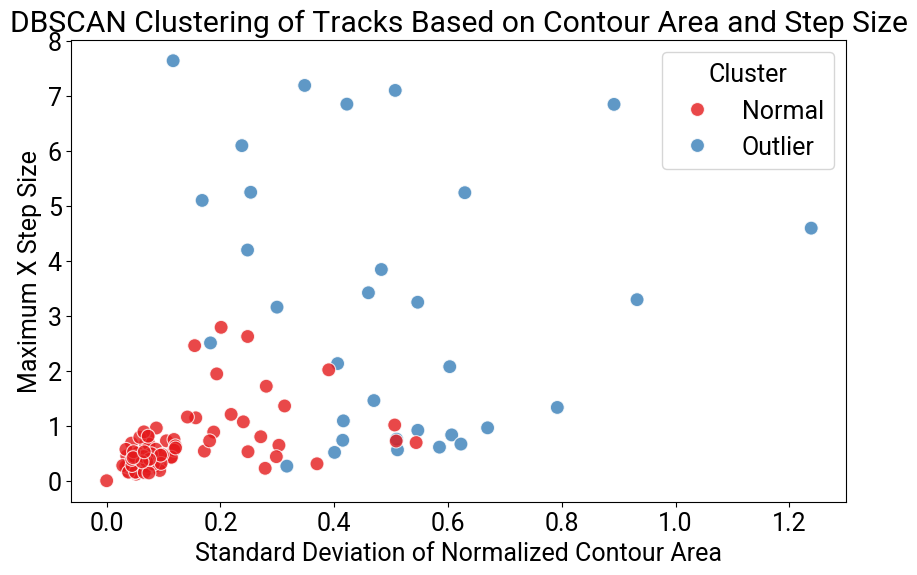

In [23]:
# Plot clustering results
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=na_only_stats_df,
    x='std_contour_area',
    y='x_max_step_size',
    hue='cluster',
    palette='Set1',
    alpha=0.8,
    s=100
)
plt.title('DBSCAN Clustering of Tracks Based on Contour Area and Step Size')
plt.xlabel('Standard Deviation of Normalized Contour Area')
plt.ylabel('Maximum X Step Size')
plt.legend(title='Cluster')
plt.show()

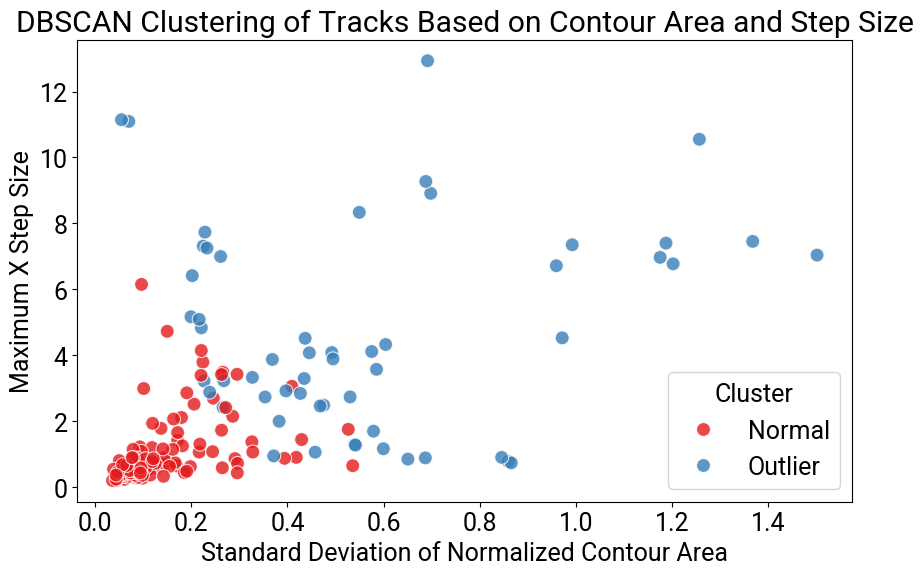

In [24]:
# Plot clustering results
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=dropna_stats_df,
    x='std_contour_area',
    y='x_max_step_size',
    hue='cluster',
    palette='Set1',
    alpha=0.8,
    s=100
)
plt.title('DBSCAN Clustering of Tracks Based on Contour Area and Step Size')
plt.xlabel('Standard Deviation of Normalized Contour Area')
plt.ylabel('Maximum X Step Size')
plt.legend(title='Cluster')
plt.show()

In [25]:
exp_df

,experiment,trackID,norm_contour_area,std_contour_area,coords,frames_list
0,20220508-FLmRNA_2x_FOV-16,0,"[0.868421052631579, 1.0, 0.9736842105263158, 0...",0.071448,"[POINT (323.73737373737373 526.6363636363636),...","[0.2, 0.3, 0.4, 0.5, 0.6000000000000001, 0.700..."
1,20220508-FLmRNA_2x_FOV-16,1,"[1.032258064516129, 0.8172043010752689, 0.8817...",0.081895,"[POINT (82.20138888888889 375.1458333333333), ...","[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6000000000000..."
2,20220508-FLmRNA_2x_FOV-16,6,"[0.9056603773584906, 0.8679245283018868, 0.886...",0.368597,"[POINT (293.6041666666667 526.7916666666666), ...","[0.2, 0.3, 0.4, 0.5, 0.6000000000000001, 0.700..."
3,20220508-FLmRNA_2x_FOV-16,11,"[1.0, 1.0869565217391304, 0.8913043478260869, ...",0.086688,"[POINT (82.55797101449275 375.4347826086956), ...","[8.5, 8.6, 8.700000000000001, 8.8, 8.9, 9.0, 9..."
4,20220508-FLmRNA_2x_FOV-16,15,"[1.1428571428571428, 1.0285714285714285, 0.971...",0.092077,"[POINT (94.5 371.7583333333333), POINT (94.5 3...","[0.1, 0.2, 0.3, 0.4, 0.5, 0.6000000000000001, ..."
...,...,...,...,...,...,...
459,20220508-FLmRNA_2x_FOV-16,8228,"[1.0895522388059702, 1.0298507462686568, 1.029...",0.034248,"[POINT (194.90867579908678 486.1598173515981),...","[19.3, 19.4, 19.5, 19.6, 19.700000000000003, 1..."
460,20220508-FLmRNA_2x_FOV-16,8246,"[1.8823529411764706, 1.8823529411764706, 0.117...",0.691020,"[POINT (328.5 574.6458333333334), POINT (328.5...","[19.200000000000003, 19.3, 19.4, 19.5, 19.6, 1..."
461,20220508-FLmRNA_2x_FOV-16,8256,"[0.8863636363636364, 1.1136363636363635, 0.977...",0.066038,"[POINT (68.73504273504273 638.3675213675214), ...","[18.2, 18.3, 18.5, 18.6, 18.7, 18.8, 18.9, 19...."
462,20220508-FLmRNA_2x_FOV-16,8373,"[0.5900621118012422, 0.546583850931677, 0.9813...",0.253161,"[POINT (257.03508771929825 525.4982456140351),...","[18.4, 18.5, 18.6, 18.7, 18.8, 18.9, 19.0, 19...."


In [26]:
unique_cluster = dropna_stats_df['cluster'].unique()
unique_cluster.sort()
unique_cluster

array(['Normal', 'Outlier'], dtype=object)

In [27]:
# Print the number of tracks in each cluster
for cluster in unique_cluster:
    num_tracks = len(dropna_stats_df[dropna_stats_df['cluster'] == cluster])
    print(f"DropNA stats:")
    print(f"    Cluster {cluster}: {num_tracks} tracks ({num_tracks / len(dropna_stats_df) * 100:.1f}%)")
    print(f"NAonly stats:")
    num_tracks_na = len(na_only_stats_df[na_only_stats_df['cluster'] == cluster])
    print(f"    Cluster {cluster}: {num_tracks_na} tracks ({num_tracks_na / len(na_only_stats_df) * 100:.1f}%)")
    print()

DropNA stats:
    Cluster Normal: 147 tracks (72.8%)
NAonly stats:
    Cluster Normal: 107 tracks (76.4%)

DropNA stats:
    Cluster Outlier: 55 tracks (27.2%)
NAonly stats:
    Cluster Outlier: 33 tracks (23.6%)



In [28]:
exp_df

,experiment,trackID,norm_contour_area,std_contour_area,coords,frames_list
0,20220508-FLmRNA_2x_FOV-16,0,"[0.868421052631579, 1.0, 0.9736842105263158, 0...",0.071448,"[POINT (323.73737373737373 526.6363636363636),...","[0.2, 0.3, 0.4, 0.5, 0.6000000000000001, 0.700..."
1,20220508-FLmRNA_2x_FOV-16,1,"[1.032258064516129, 0.8172043010752689, 0.8817...",0.081895,"[POINT (82.20138888888889 375.1458333333333), ...","[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6000000000000..."
2,20220508-FLmRNA_2x_FOV-16,6,"[0.9056603773584906, 0.8679245283018868, 0.886...",0.368597,"[POINT (293.6041666666667 526.7916666666666), ...","[0.2, 0.3, 0.4, 0.5, 0.6000000000000001, 0.700..."
3,20220508-FLmRNA_2x_FOV-16,11,"[1.0, 1.0869565217391304, 0.8913043478260869, ...",0.086688,"[POINT (82.55797101449275 375.4347826086956), ...","[8.5, 8.6, 8.700000000000001, 8.8, 8.9, 9.0, 9..."
4,20220508-FLmRNA_2x_FOV-16,15,"[1.1428571428571428, 1.0285714285714285, 0.971...",0.092077,"[POINT (94.5 371.7583333333333), POINT (94.5 3...","[0.1, 0.2, 0.3, 0.4, 0.5, 0.6000000000000001, ..."
...,...,...,...,...,...,...
459,20220508-FLmRNA_2x_FOV-16,8228,"[1.0895522388059702, 1.0298507462686568, 1.029...",0.034248,"[POINT (194.90867579908678 486.1598173515981),...","[19.3, 19.4, 19.5, 19.6, 19.700000000000003, 1..."
460,20220508-FLmRNA_2x_FOV-16,8246,"[1.8823529411764706, 1.8823529411764706, 0.117...",0.691020,"[POINT (328.5 574.6458333333334), POINT (328.5...","[19.200000000000003, 19.3, 19.4, 19.5, 19.6, 1..."
461,20220508-FLmRNA_2x_FOV-16,8256,"[0.8863636363636364, 1.1136363636363635, 0.977...",0.066038,"[POINT (68.73504273504273 638.3675213675214), ...","[18.2, 18.3, 18.5, 18.6, 18.7, 18.8, 18.9, 19...."
462,20220508-FLmRNA_2x_FOV-16,8373,"[0.5900621118012422, 0.546583850931677, 0.9813...",0.253161,"[POINT (257.03508771929825 525.4982456140351),...","[18.4, 18.5, 18.6, 18.7, 18.8, 18.9, 19.0, 19...."


['20220508-FLmRNA_2x_FOV-16']
['20220508-FLmRNA_2x_FOV-16']


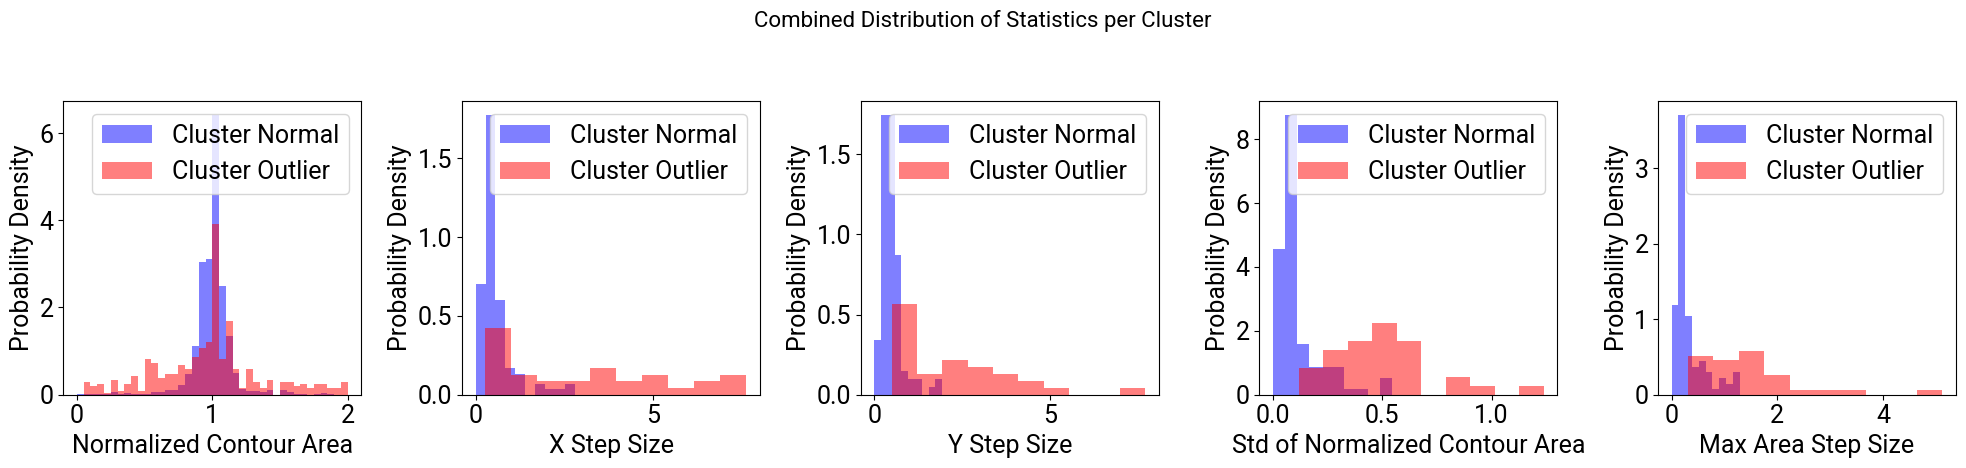

['20220508-FLmRNA_2x_FOV-16']
['20220508-FLmRNA_2x_FOV-16']


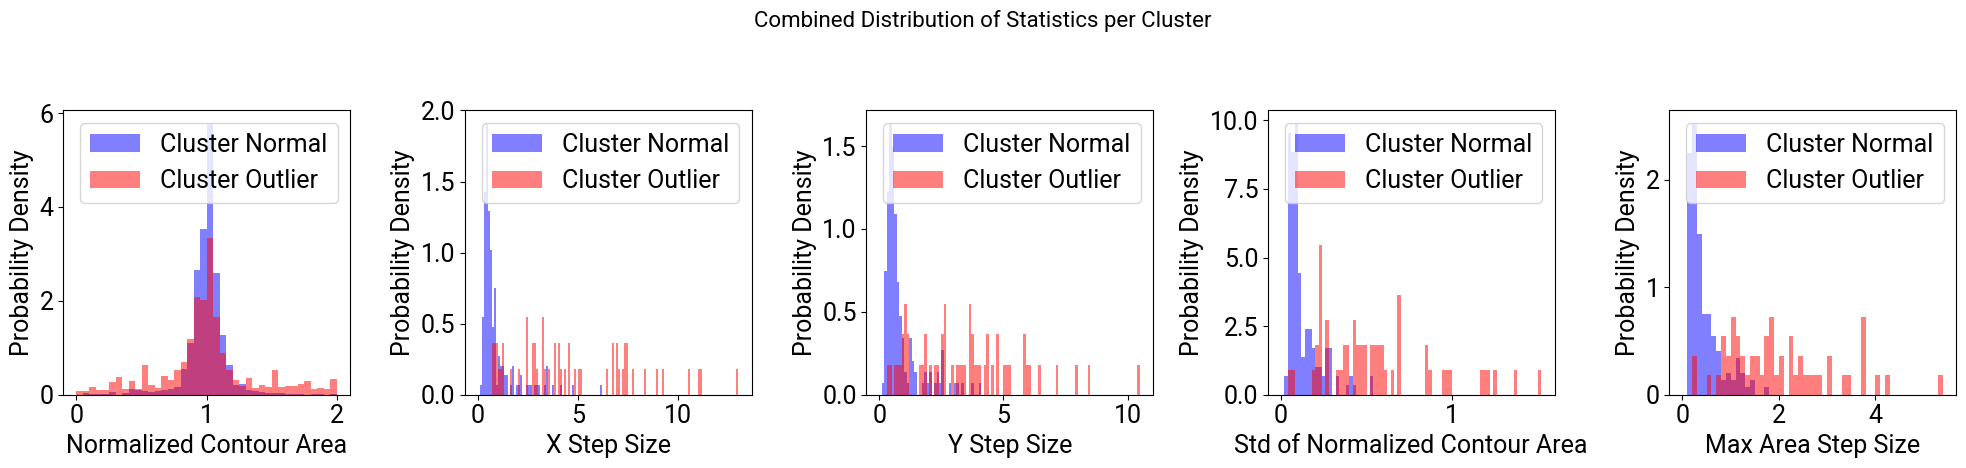

In [31]:
def plot_cluster_distributions(stats_df_to_plot, exp_df, colors, save_path=None):
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))

    # A dictionary to hold the data for each metric for each cluster
    cluster_data = {
        'norm_contour_areas': {},
        'x_step_sizes': {},
        'y_step_sizes': {},
        'std_contour_areas': {},
        'max_area_step_sizes': {}
    }

    unique_cluster = stats_df_to_plot['cluster'].unique()

    for cluster_id in unique_cluster:
        cluster_df = stats_df_to_plot[stats_df_to_plot['cluster'] == cluster_id]
        unique_experiments = cluster_df['experiment'].unique()
        print(unique_experiments)
        # Initialize lists for the current cluster
        norm_contour_areas = []
        x_step_sizes = []
        y_step_sizes = []
        std_contour_areas = []
        max_area_step_sizes = []

        for experiment in unique_experiments:
            experiment_df = cluster_df[cluster_df['experiment'] == experiment]
            for track_id in experiment_df['trackID']:
                # Append norm_contour_area
                exp_df_track = exp_df[(exp_df['trackID'] == track_id) & (exp_df['experiment'] == experiment)]
                if not exp_df_track.empty:
                    norm_contour_areas.extend(exp_df_track['norm_contour_area'].values[0])
                
                # Append other stats from stats_df
                stats_row = cluster_df[cluster_df['trackID'] == track_id].iloc[0]
                x_step_sizes.append(stats_row['x_max_step_size'])
                y_step_sizes.append(stats_row['y_max_step_size'])
                std_contour_areas.append(stats_row['std_contour_area'])
                max_area_step_sizes.append(stats_row['area_max_step_size'])

            # Store the collected data
            if norm_contour_areas:
                cluster_data['norm_contour_areas'][cluster_id] = np.concatenate([norm_contour_areas])
            else:
                cluster_data['norm_contour_areas'][cluster_id] = np.array([])
            cluster_data['x_step_sizes'][cluster_id] = np.array(x_step_sizes)
            cluster_data['y_step_sizes'][cluster_id] = np.array(y_step_sizes)
            cluster_data['std_contour_areas'][cluster_id] = np.array(std_contour_areas)
            cluster_data['max_area_step_sizes'][cluster_id] = np.array(max_area_step_sizes)

    # Plotting
    metric_info = {
        'norm_contour_areas': {'ax_idx': 0, 'label': 'Normalized Contour Area', 'bin_width': 0.05, 'range_max': 2},
        'x_step_sizes': {'ax_idx': 1, 'label': 'X Step Size', 'bin_width': 0.1, 'range_max': None},
        'y_step_sizes': {'ax_idx': 2, 'label': 'Y Step Size', 'bin_width': 0.1, 'range_max': None},
        'std_contour_areas': {'ax_idx': 3, 'label': 'Std of Normalized Contour Area', 'bin_width': 0.02, 'range_max': None},
        'max_area_step_sizes': {'ax_idx': 4, 'label': 'Max Area Step Size', 'bin_width': 0.1, 'range_max': None}
    }

    for metric, info in metric_info.items():
        ax = axes[info['ax_idx']]
        
        all_values_list = [v for v in cluster_data[metric].values() if v.size > 0]
        if not all_values_list:
            continue
        all_values = np.concatenate(all_values_list)
        
        if info['range_max'] is None:
            if all_values.size > 0:
                range_max = np.max(all_values)
            else:
                range_max = 1
        else:
            range_max = info['range_max']
            
        try:
            bins = np.arange(0, range_max + info['bin_width'], info['bin_width'])
        except:
            bins = 10
        
        for i, cluster_id in enumerate(unique_cluster):
            if cluster_data[metric][cluster_id].size > 0:
                ax.hist(cluster_data[metric][cluster_id], bins=bins, color=colors[i % len(colors)], alpha=0.5, label=f'Cluster {cluster_id}', density=True)

        ax.set_xlabel(info['label'])
        ax.set_ylabel('Probability Density')
        ax.legend()

    fig.suptitle('Combined Distribution of Statistics per Cluster', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    if save_path is not None:
        plt.savefig(save_path, dpi=300)
    plt.show()

colors = ['blue', 'red', 'green', 'purple', 'orange']

data_name = 'test'

plot_cluster_distributions(na_only_stats_df, exp_df, colors, save_path=os.path.join(img_path, f"{data_name}_na.png"))
plot_cluster_distributions(dropna_stats_df, exp_df, colors, save_path=os.path.join(img_path, f"{data_name}_dropna.png"))

IndexError: index 0 is out of bounds for axis 0 with size 0

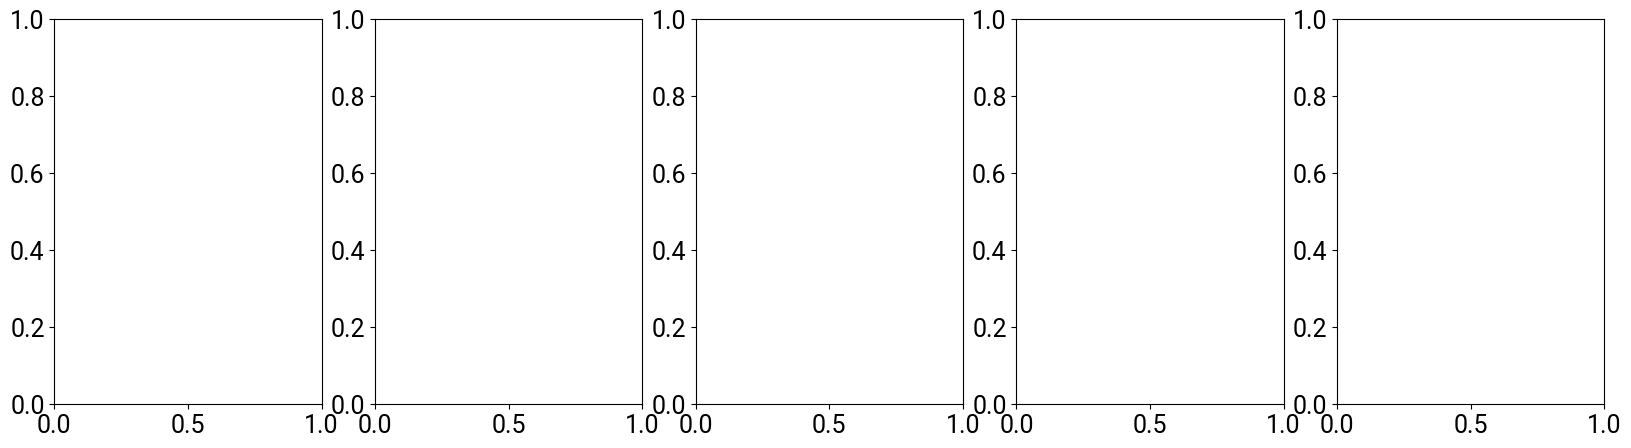

In [30]:
# Define colors for the clusters
colors = ['blue', 'red', 'green', 'purple', 'orange']

# There are 4 metrics to plot
# 1. Normalized Contour Area
# 2. X Step Size
# 3. Y Step Size
# 4. Std of Normalized Contour Area
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# A dictionary to hold the data for each metric for each cluster
cluster_data = {
    'norm_contour_areas': {},
    'x_step_sizes': {},
    'y_step_sizes': {},
    'std_contour_areas': {},
    'max_area_step_sizes': {}
}

for cluster_id in unique_cluster:
    cluster_df = dropna_stats_df[dropna_stats_df['cluster'] == cluster_id]
    
    # Initialize lists for the current cluster
    norm_contour_areas = []
    x_step_sizes = []
    y_step_sizes = []
    std_contour_areas = []
    max_area_step_sizes = []

    for track_id in cluster_df.index:
        # Append norm_contour_area
        exp_df_track = exp_df[exp_df['trackID'] == track_id]
        norm_contour_areas.extend(exp_df_track['norm_contour_area'].values[0])
        
        # Append other stats from stats_df
        stats_row = cluster_df.loc[track_id]
        x_step_sizes.append(stats_row['x_max_step_size'])
        y_step_sizes.append(stats_row['y_max_step_size'])
        std_contour_areas.append(stats_row['std_contour_area'])
        max_area_step_sizes.append(stats_row['area_max_step_size'])

    # Store the collected data
    cluster_data['norm_contour_areas'][cluster_id] = np.concatenate([norm_contour_areas])
    cluster_data['x_step_sizes'][cluster_id] = np.array(x_step_sizes)
    cluster_data['y_step_sizes'][cluster_id] = np.array(y_step_sizes)
    cluster_data['std_contour_areas'][cluster_id] = np.array(std_contour_areas)
    cluster_data['max_area_step_sizes'][cluster_id] = np.array(max_area_step_sizes)

# Plotting
metric_info = {
    'norm_contour_areas': {'ax_idx': 0, 'label': 'Normalized Contour Area', 'bin_width': 0.05, 'range_max': 2},
    'x_step_sizes': {'ax_idx': 1, 'label': 'X Step Size', 'bin_width': 0.1, 'range_max': None},
    'y_step_sizes': {'ax_idx': 2, 'label': 'Y Step Size', 'bin_width': 0.1, 'range_max': None},
    'std_contour_areas': {'ax_idx': 3, 'label': 'Std of Normalized Contour Area', 'bin_width': 0.02, 'range_max': None},
    'max_area_step_sizes': {'ax_idx': 4, 'label': 'Max Area Step Size', 'bin_width': 0.1, 'range_max': None}
}

for metric, info in metric_info.items():
    ax = axes[info['ax_idx']]
    all_values = np.concatenate(list(cluster_data[metric].values()))
    
    if info['range_max'] is None:
        range_max = np.max(all_values)
    else:
        range_max = info['range_max']
        
    bins = np.arange(0, range_max + info['bin_width'], info['bin_width'])
    
    for i, cluster_id in enumerate(unique_cluster):
        ax.hist(cluster_data[metric][cluster_id], bins=bins, color=colors[i % len(colors)], alpha=0.5, label=f'Cluster {cluster_id}', density=True)

    ax.set_xlabel(info['label'])
    ax.set_ylabel('Probability Density')
    ax.legend()

fig.suptitle('Combined Distribution of Statistics per Cluster', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# A dictionary to hold the data for each metric for each cluster
cluster_data = {
    'norm_contour_areas': {},
    'x_step_sizes': {},
    'y_step_sizes': {},
    'std_contour_areas': {},
    'max_area_step_sizes': {}
}

unique_cluster = na_only_stats_df['cluster'].unique()

for cluster_id in unique_cluster:
    cluster_df = na_only_stats_df[na_only_stats_df['cluster'] == cluster_id]
    
    # Initialize lists for the current cluster
    norm_contour_areas = []
    x_step_sizes = []
    y_step_sizes = []
    std_contour_areas = []
    max_area_step_sizes = []

    for track_id in cluster_df.index:
        # Append norm_contour_area
        exp_df_track = exp_df[exp_df['trackID'] == track_id]
        norm_contour_areas.extend(exp_df_track['norm_contour_area'].values[0])
        
        # Append other stats from stats_df
        stats_row = cluster_df.loc[track_id]
        x_step_sizes.append(stats_row['x_max_step_size'])
        y_step_sizes.append(stats_row['y_max_step_size'])
        std_contour_areas.append(stats_row['std_contour_area'])
        max_area_step_sizes.append(stats_row['area_max_step_size'])

    # Store the collected data
    cluster_data['norm_contour_areas'][cluster_id] = np.concatenate([norm_contour_areas])
    cluster_data['x_step_sizes'][cluster_id] = np.array(x_step_sizes)
    cluster_data['y_step_sizes'][cluster_id] = np.array(y_step_sizes)
    cluster_data['std_contour_areas'][cluster_id] = np.array(std_contour_areas)
    cluster_data['max_area_step_sizes'][cluster_id] = np.array(max_area_step_sizes)

# Plotting
metric_info = {
    'norm_contour_areas': {'ax_idx': 0, 'label': 'Normalized Contour Area', 'bin_width': 0.05, 'range_max': 2},
    'x_step_sizes': {'ax_idx': 1, 'label': 'X Step Size', 'bin_width': 0.1, 'range_max': None},
    'y_step_sizes': {'ax_idx': 2, 'label': 'Y Step Size', 'bin_width': 0.1, 'range_max': None},
    'std_contour_areas': {'ax_idx': 3, 'label': 'Std of Normalized Contour Area', 'bin_width': 0.02, 'range_max': None},
    'max_area_step_sizes': {'ax_idx': 4, 'label': 'Max Area Step Size', 'bin_width': 0.1, 'range_max': None}
}

for metric, info in metric_info.items():
    ax = axes[info['ax_idx']]
    all_values = np.concatenate(list(cluster_data[metric].values()))
    
    if info['range_max'] is None:
        range_max = np.max(all_values)
    else:
        range_max = info['range_max']
        
    try:
        bins = np.arange(0, range_max + info['bin_width'], info['bin_width'])
    except:
        bins = 10
    
    for i, cluster_id in enumerate(unique_cluster):
        ax.hist(cluster_data[metric][cluster_id], bins=bins, color=colors[i % len(colors)], alpha=0.5, label=f'Cluster {cluster_id}', density=True)

    ax.set_xlabel(info['label'])
    ax.set_ylabel('Probability Density')
    ax.legend()

fig.suptitle('Combined Distribution of Statistics per Cluster', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
def plot_cluster_tracks(stats_df, exp_df, filtered_df, experiment, img_path, file_prefix=''):
    """
    Plots the tracks for each cluster and saves the figures.

    Args:
        stats_df (pd.DataFrame): DataFrame with statistics and cluster labels for tracks.
        exp_df (pd.DataFrame): DataFrame with detailed experiment data (coords, contour area).
        filtered_df (pd.DataFrame): DataFrame with filtered raw data (distance, time).
        experiment (str): The name of the experiment, used for saving files.
        img_path (str): The path to the directory where images will be saved.
    """
    unique_cluster = stats_df['cluster'].unique()
    unique_cluster.sort()

    for cluster_id in unique_cluster:
        cluster_tracks = stats_df[stats_df['cluster'] == cluster_id]
        track_ids = cluster_tracks.index.tolist()
        
        if not track_ids:
            print(f"No tracks in cluster {cluster_id} to plot.")
            continue

        cluster_num_points = len(track_ids)
        num_col = 4
        
        # Check for number of NA points
        num_na_points = cluster_tracks.isna().sum().sum()
        num_row = cluster_num_points - num_na_points
        


        fig, ax = plt.subplots(num_row, num_col, figsize=(12, 3 * num_row), squeeze=False)
        # fig.suptitle(f'Cluster {cluster_id} Tracks', fontsize=16)

        for i, track_id in enumerate(track_ids):
            row = i 
            
            # Plot X and Y position over time
            ax[row, 0].set_title(f'ID: {track_id}')
            coords = exp_df[exp_df['trackID'] == track_id]['coords'].values[0]
            frames = exp_df[exp_df['trackID'] == track_id]['frames_list'].values[0]
            
            x_vals = [point.x for point in coords if point is not None]
            y_vals = [point.y for point in coords if point is not None]
            
            try:
                ax[row, 0].plot(frames, x_vals, label='X Position', color='blue')
            except:
                pass
            ax2 = ax[row, 0].twinx()
            try:
                ax2.plot(frames, y_vals, label='Y Position', color='orange')
            except:
                pass
            ax[row, 0].set_xlabel('Time (s)')
            ax[row, 0].set_ylabel('X Position', color='blue')
            ax2.set_ylabel('Y Position', color='orange')
            
            # Plot the norm contour area as a histogram
            norm_contour_area = exp_df[exp_df['trackID'] == track_id]['norm_contour_area'].values[0]
            bin_width = 0.05
            bins = np.arange(0, max(2, np.max(norm_contour_area) + bin_width), bin_width)
            ax[row, 1].hist(norm_contour_area, bins=bins, color='green', alpha=0.7)
            ax[row, 1].set_xlabel('Normalized Contour Area')
            ax[row, 1].set_ylabel('Frequency')
                
            # Plot the distance over time
            track_df = filtered_df[filtered_df['trackID'] == track_id]
            distance = track_df['distance_um'].values
            t = track_df['t'].values
            ax[row, 2].plot(t, distance, color='brown')
            ax[row, 2].set_xlabel('Time (s)')
            ax[row, 2].set_ylabel('Distance (um)')

            # Plot the trajectory
            ax[row, 3].plot(x_vals, y_vals, marker='o', markersize=3, linestyle='-', color='tab:blue', alpha=0.5)
            ax[row, 3].set_xlabel('X Position')
            ax[row, 3].set_ylabel('Y Position')
            ax[row, 3].set_aspect('equal', adjustable='box')

            if x_vals and y_vals:
                x_length = int(np.max(x_vals) - np.min(x_vals))
                y_length = int(np.max(y_vals) - np.min(y_vals))
                center_x = (np.max(x_vals) + np.min(x_vals)) / 2
                center_y = (np.max(y_vals) + np.min(y_vals)) / 2

                window_size = max(x_length, y_length, 1)
                box_length = window_size * 2

                ax[row, 3].set_xlim(center_x - 0.5 * box_length, center_x + 0.5 * box_length)
                ax[row, 3].set_ylim(center_y - 0.5 * box_length, center_y + 0.5 * box_length)
            
            ax[row, 3].tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

        plt.tight_layout(rect=[1, 1, 1, 0.98])

        plt.savefig(os.path.join(img_path, f'cluster_{experiment}_{cluster_id}_{file_prefix}_tracks.png'))
        plt.close()


In [ ]:
plot_cluster_tracks(dropna_stats_df, exp_df, filtered_df, experiment, img_path, file_prefix='dropna')

In [ ]:
plot_cluster_tracks(na_only_stats_df, exp_df, filtered_df, experiment, img_path, file_prefix='na_only')

In [ ]:
check_idx = 226
norm_contour_area = np.array(norm_contour_area_list[check_idx])
std_contour_area = std_contour_area_list[check_idx]
track_id = track_id_list[check_idx]

import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], width_ratios=[1, 1, 1], wspace=0.3, hspace=0.3)

# ax[0] - Histogram
ax0 = fig.add_subplot(gs[:, 0])
bin_width = 0.05
ax0.hist(norm_contour_area, bins=np.arange(np.round(np.min(norm_contour_area), 2), np.round(np.max(norm_contour_area), 2) + bin_width, bin_width), histtype='step', density=False)
ax0.set_xlabel(f"Norm area, std: {std_contour_area:.2f}")
ax0.set_ylabel("Count")

# ax[1] - Trajectory
ax1 = fig.add_subplot(gs[:, 1])
coords = coords_list[check_idx]
x_vals = [point.x for point in coords if point is not None]
y_vals = [point.y for point in coords if point is not None]

x_max_step_size = np.max(np.abs(np.diff(x_vals)))
y_max_step_size = np.max(np.abs(np.diff(y_vals)))
print(f"Max step size\nX: {x_max_step_size:.2f}\nY: {y_max_step_size:.2f}")

ax1.plot(x_vals, y_vals, marker='o', linestyle='-', alpha=0.3)

x_length = int(np.max(x_vals) - np.min(x_vals))
y_length = int(np.max(y_vals) - np.min(y_vals))
center_x = (np.max(x_vals) + np.min(x_vals)) / 2
center_y = (np.max(y_vals) + np.min(y_vals)) / 2

window_size = max(x_length, y_length, 1)
box_length = window_size * 2

ax1.set_xlim(center_x - 0.5 * box_length, center_x + 0.5 * box_length)
ax1.set_ylim(center_y - 0.5 * box_length, center_y + 0.5 * box_length)
ax1.set_aspect('equal', adjustable='box')
ax1.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

modal_value, count = mode(norm_contour_area)
print(f"Modal value: {modal_value:.2f}, Count: {count}")

# Normality check

if len(norm_contour_area) > 20:
    stat, p = normaltest(norm_contour_area)
    alpha = 0.05
    if p < alpha:
        print(f"The data is not normally distributed (reject H0), p-value: {p}")
    else:
        print("The data is normally distributed (fail to reject H0)")
else:
    print("Not enough data points to perform normality test.")

# Right-side plots
ax2_top = fig.add_subplot(gs[0, 2])
ax2_bottom = fig.add_subplot(gs[1, 2])

# ax[2] top: x vs frame
frames = exp_df.loc[check_idx, 'frames_list']
ax2_top.plot(frames, x_vals, marker='o', linestyle='-')
ax2_top.set_ylabel("X position")
ax2_top.tick_params(bottom=False, labelbottom=False)
ax2_top.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))

# ax[2] bottom: y vs frame
ax2_bottom.plot(frames, y_vals, marker='o', linestyle='-')
ax2_bottom.set_xlabel("Frame")
ax2_bottom.set_ylabel("Y position")
ax2_bottom.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
ax2_bottom.xaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))

plt.suptitle(f"{experiment}, #{track_id}", fontsize=16)

output_dir = 'result/filtering_img'
plt.savefig(os.path.join(output_dir, f"{experiment}_{track_id}.png"), bbox_inches='tight')

plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
count = 0
for norm_contour_area in norm_contour_area_list:
    ax.plot(np.arange(len(norm_contour_area)), norm_contour_area, alpha=0.3, lw=0.2)
    if np.max(norm_contour_area) > 1.3 or np.min(norm_contour_area) < 0.7:
        count += 1
    ax.set_xlabel("Frame")
    ax.set_ylabel("Normalized Contour Area")
    ax.set_title(f"Experiment: {experiment}")    
     
ax.axhline(1.3, color='black', linestyle='--', label='Upper threshold (1.3)')
ax.axhline(0.7, color='black', linestyle='--', label='Lower threshold (0.7)')

ax.set_ylim(0.5, 1.5)

plt.tight_layout()
print(f"Number of tracks with outliers: {count} out of {len(track_id_list)} ({count/len(track_id_list)*100:.2f}%)")

In [ ]:
temp_t_dwell_df

In [ ]:
df

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(12,12))
bin_width = 0.05

ax[0].hist(all_norm_contour_area, bins=np.arange(0, 6 + bin_width, bin_width), histtype='step', density=True)

ax[0].set_xlabel("Normalized contour area")
ax[0].set_ylabel("Probability density")
ax[0].set_title(f"Experiment: {experiment}")
ax[0].set_xlim(0.5, 1.5)

ax[1].hist(all_std_contour_area, bins=np.arange(0, 6 + bin_width, bin_width), histtype='step', density=True)
ax[1].set_xlabel("Standard deviation of normalized contour area")
ax[1].set_ylabel("Probability density")
ax[1].set_xlim(0, 0.5)

fig.tight_layout()